# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [29]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro')
    baseline_results[name] = (cv_scores.mean(), cv_scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9717 ± 0.0159
RandomForest              F1 = 0.9528 ± 0.0244
LogisticRegression        F1 = 0.9792 ± 0.0072


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [31]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
    svm_pipe, 
    svm_param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
)
svm_grid_search.fit(X_train, y_train) 

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [32]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
results_df = pd.DataFrame(svm_grid_search.cv_results_)

selected_columns = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
results_selected = results_df[selected_columns]
best_results = results_selected.sort_values('rank_test_score').head(10)

display_df = best_results.copy()
display_df['mean_test_score'] = display_df['mean_test_score'].map(lambda x: f"{x:.4f}")
display_df['std_test_score'] = display_df['std_test_score'].map(lambda x: f"{x:.4f}")
display_df

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.9786,0.0176,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.9762,0.0153,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.9762,0.0153,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.9762,0.0153,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.9762,0.0170,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.9713,0.0163,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.9694,0.0193,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.9693,0.0192,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.9669,0.0175,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.9667,0.0252,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20), 
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_base = RandomForestClassifier(random_state=42)

rf_random_search = RandomizedSearchCV(
    rf_base,
    rf_param_dist,
    n_iter=50,  
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [34]:
!pip install prettytable


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
print("Лучшая модель SVM (Grid Search)")
y_pred_svm_best = svm_grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_svm_best))
print(f"Test F1 Score: {f1_score(y_test, y_pred_svm_best, average='macro'):.4f}")

print("Лучшая модель случайного леса (Randomized Search)")
y_pred_rf_best = rf_random_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_rf_best))
print(f"Test F1 Score: {f1_score(y_test, y_pred_rf_best, average='macro'):.4f}")

print("Сравнение результатов")

print("\nОценка baseline моделей на тестовых данных:")
y_pred_svm_base = base_models['SVM'].fit(X_train, y_train).predict(X_test)
f1_svm_base_test = f1_score(y_test, y_pred_svm_base, average='macro')

y_pred_rf_base = base_models['RandomForest'].fit(X_train, y_train).predict(X_test)
f1_rf_base_test = f1_score(y_test, y_pred_rf_base, average='macro')

y_pred_lr_base = base_models['LogisticRegression'].fit(X_train, y_train).predict(X_test)
f1_lr_base_test = f1_score(y_test, y_pred_lr_base, average='macro')

from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Модель", "CV F1 (mean±std)", "Test F1"]
table.align["Модель"] = "l"
table.align["CV F1 (mean±std)"] = "c"
table.align["Test F1"] = "c"
# Добавляем строки
table.add_row([
    "SVM baseline",
    f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
    f"{f1_svm_base_test:.4f}"
])
table.add_row([
    "SVM Grid Search",
    f"{svm_grid_search.best_score_:.4f} ± {svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_]:.4f}",
    f"{f1_score(y_test, y_pred_svm_best, average='macro'):.4f}"
])
table.add_row([
    "RF baseline",
    f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
    f"{f1_rf_base_test:.4f}"
])
table.add_row([
    "RF Random Search",
    f"{rf_random_search.best_score_:.4f} ± {rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f}",
    f"{f1_score(y_test, y_pred_rf_best, average='macro'):.4f}"
])
table.add_row([
    "Logistic Regression baseline",
    f"{baseline_results['LogisticRegression'][0]:.4f} ± {baseline_results['LogisticRegression'][1]:.4f}",
    f"{f1_lr_base_test:.4f}"
])
print(table)
# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

Лучшая модель SVM (Grid Search)
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Test F1 Score: 0.9812
Лучшая модель случайного леса (Randomized Search)
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Test F1 Score: 0.9526
Сравнение результатов

Оценка baseline моделей на тестовых данных:
+------------------------------+------------------+---------+
| Модель                       | CV F1 (mean±std) | Test F1 |
+----------------------------

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

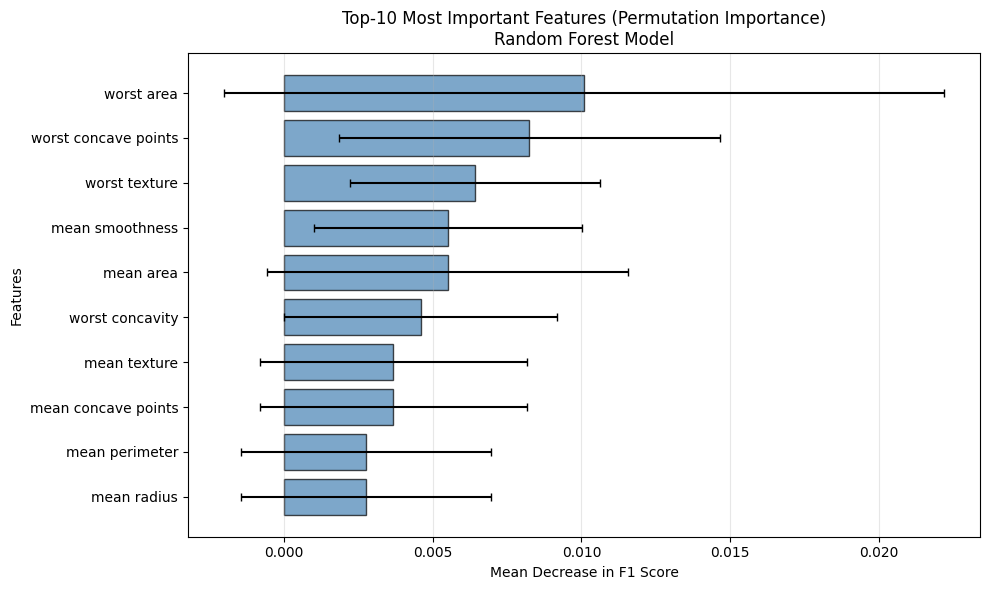

In [36]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(
    best_rf, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1_macro',
    n_jobs=-1  # используем все ядра для ускорения
)

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
feature_importance = pi_result.importances_mean
feature_importance_std = pi_result.importances_std
feature_indices = np.argsort(feature_importance)[::-1]

n_top_features = 10
top_indices = feature_indices[:n_top_features]
top_features = top_indices
top_importance = feature_importance[top_indices]
top_importance_std = feature_importance_std[top_indices]

if hasattr(X_test, 'columns'):
    feature_names = X_test.columns
else:
    feature_names = [f'Feature {i}' for i in range(X_test.shape[1])]

plt.figure(figsize=(10, 6))
y_pos = np.arange(len(top_features))

plt.barh(y_pos, top_importance, xerr=top_importance_std, 
         capsize=3, alpha=0.7, color='steelblue', edgecolor='black')
plt.yticks(y_pos, [feature_names[i] for i in top_features])
plt.xlabel('Mean Decrease in F1 Score')
plt.ylabel('Features')
plt.title(f'Top-{n_top_features} Most Important Features (Permutation Importance)\nRandom Forest Model')
plt.gca().invert_yaxis()  # Чтобы самый важный признак был сверху
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

builtin_importance = best_rf.feature_importances_
importance_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Permutation_Importance': feature_importance,
    'Permutation_Std': feature_importance_std,
    'Builtin_Importance': builtin_importance
})

importance_comparison['Rank_Permutation'] = importance_comparison['Permutation_Importance'].rank(ascending=False, method='dense').astype(int)
importance_comparison['Rank_Builtin'] = importance_comparison['Builtin_Importance'].rank(ascending=False, method='dense').astype(int)
importance_comparison['Rank_Difference'] = abs(importance_comparison['Rank_Permutation'] - importance_comparison['Rank_Builtin'])

print("Сравнение топ-5 признаков:")

top5_permutation = importance_comparison.nlargest(5, 'Permutation_Importance')[['Feature', 'Permutation_Importance', 'Builtin_Importance']]
top5_builtin = importance_comparison.nlargest(5, 'Builtin_Importance')[['Feature', 'Builtin_Importance', 'Permutation_Importance']]

print("\nТоп-5 по Permutation Importance:")
for idx, row in top5_permutation.iterrows():
    print(f"{row['Feature']:<30} | PI: {row['Permutation_Importance']:.6f} | Built-in: {row['Builtin_Importance']:.6f}")

print("\nТоп-5 по Built-in Importance:")
for idx, row in top5_builtin.iterrows():
    print(f"{row['Feature']:<30} | Built-in: {row['Builtin_Importance']:.6f} | PI: {row['Permutation_Importance']:.6f}")

top5_perm_features = set(top5_permutation['Feature'].values)
top5_builtin_features = set(top5_builtin['Feature'].values)
common_features = top5_perm_features & top5_builtin_features

print("\nИтого")
print(f"Совпадающие признаки в топ-5: {len(common_features)} из 5")
print(f"Общие признаки: {common_features if common_features else 'Нет общих признаков'}")

if len(common_features) == 5:
    print("Порядок топ-5 признаков полностью совпадает!")
elif len(common_features) >= 3:
    print("Порядок топ-5 признаков частично совпадает (есть различия)")
else:
    print("Порядок топ-5 признаков сильно отличается!")

Сравнение топ-5 признаков:

Топ-5 по Permutation Importance:
worst area                     | PI: 0.010087 | Built-in: 0.127064
worst concave points           | PI: 0.008251 | Built-in: 0.109349
worst texture                  | PI: 0.006430 | Built-in: 0.018821
mean smoothness                | PI: 0.005511 | Built-in: 0.008394
mean area                      | PI: 0.005503 | Built-in: 0.054590

Топ-5 по Built-in Importance:
worst area                     | Built-in: 0.127064 | PI: 0.010087
worst perimeter                | Built-in: 0.114167 | PI: 0.000963
worst concave points           | Built-in: 0.109349 | PI: 0.008251
worst radius                   | Built-in: 0.082528 | PI: 0.001812
mean concave points            | Built-in: 0.072224 | PI: 0.003674

Итого
Совпадающие признаки в топ-5: 2 из 5
Общие признаки: {'worst area', 'worst concave points'}
Порядок топ-5 признаков сильно отличается!


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

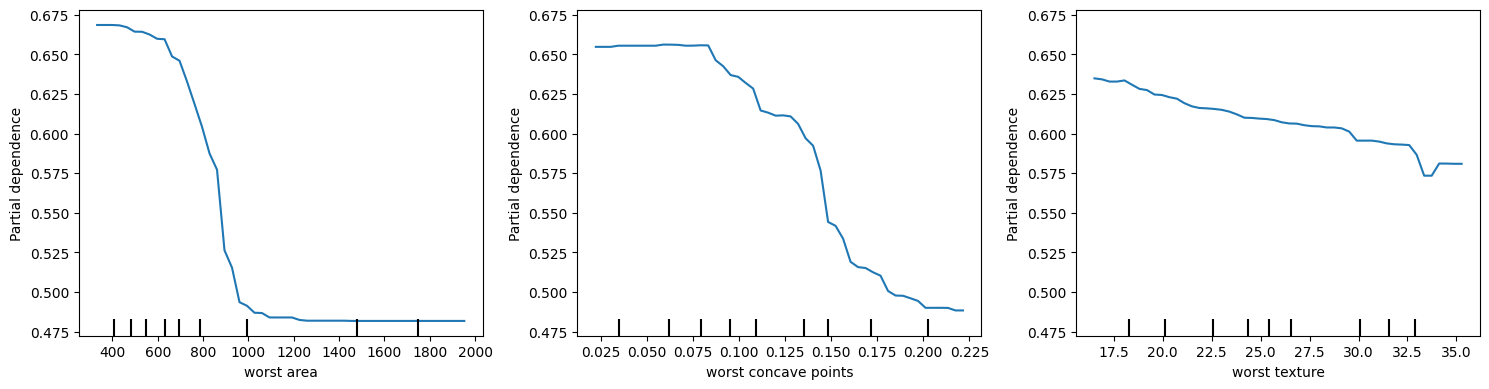

In [38]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = feature_indices[:3]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(
    best_rf, 
    X_test, 
    features=top3_idx,
    kind='average',  # PDP
    ax=ax,
    grid_resolution=50
)
plt.tight_layout()
plt.show()

Анализ ICE для признака: worst area


Task was destroyed but it is pending!
task: <Task pending name='Task-121' coro=<_async_in_context.<locals>.run_in_context() done, defined at F:\Прога\DS-ML\ml-famcs-course-homeworks\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-122' coro=<Kernel.shell_main() running at F:\Прога\DS-ML\ml-famcs-course-homeworks\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at F:\Прога\DS-ML\ml-famcs-course-homeworks\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-122' coro=<Kernel.shell_main() running at F:\Прога\DS-ML\ml-famcs-course-homeworks\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


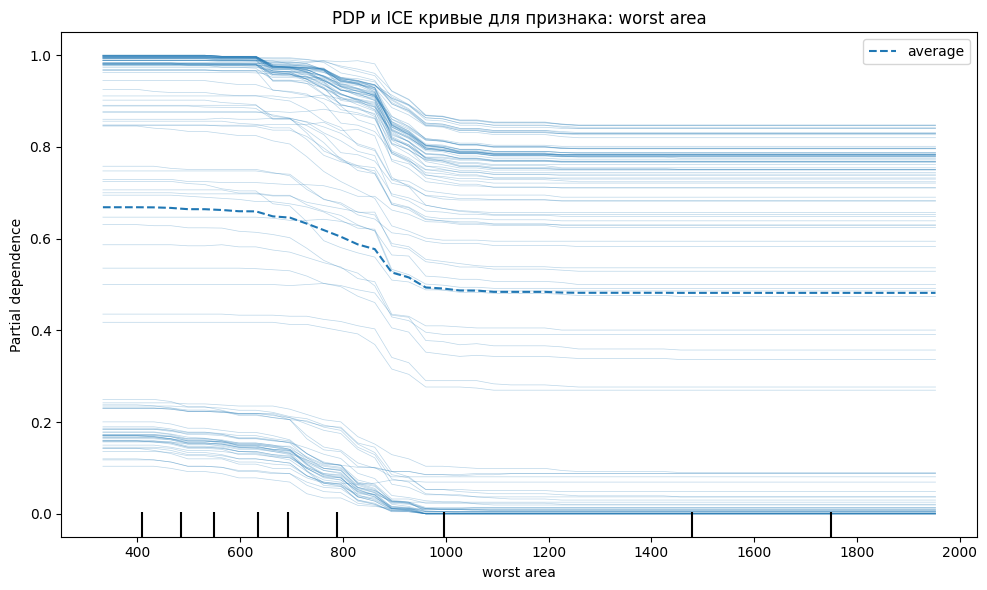

In [39]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
most_important_idx = feature_indices[0] 
most_important_name = feature_names[most_important_idx]

print(f"Анализ ICE для признака: {most_important_name}")

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=[most_important_idx],
    kind='both',  
    ax=ax,
    grid_resolution=50,
    random_state=42
)

ax.set_title(f'PDP и ICE кривые для признака: {most_important_name}')
plt.tight_layout()
plt.show()

Анализ однородности

Статистика разброса ICE кривых:
  Среднее стандартное отклонение: 0.3516
  Средний размах (max-min): 0.8775
  Максимальный разброс в точке: 0.9697 при значении 828.72


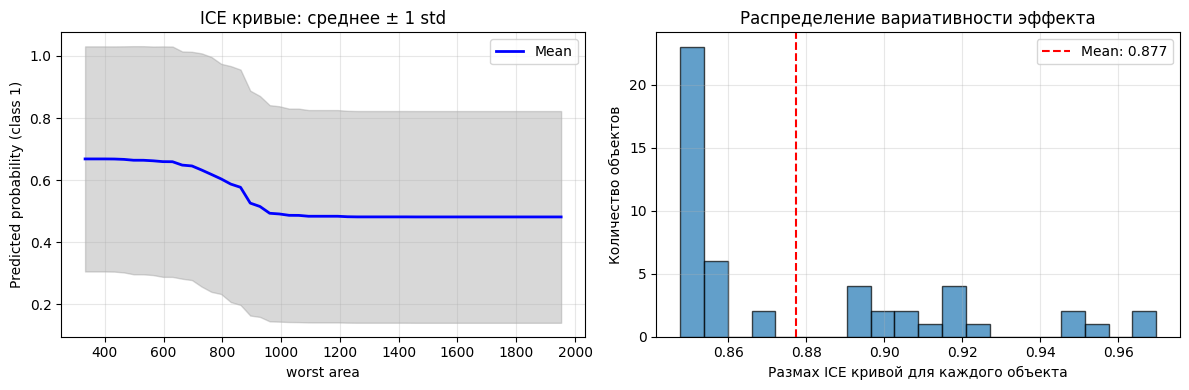


Эффект признака 'worst area': неоднороден
Причина: Эффект сильно различается для разных объектов, есть взаимодействия с другими признаками
Коэффициент вариации: 0.651

Эффект неоднороден - есть взаимодействия с другими признаками
Рекомендуется проанализировать взаимодействие с топ-2 признаками


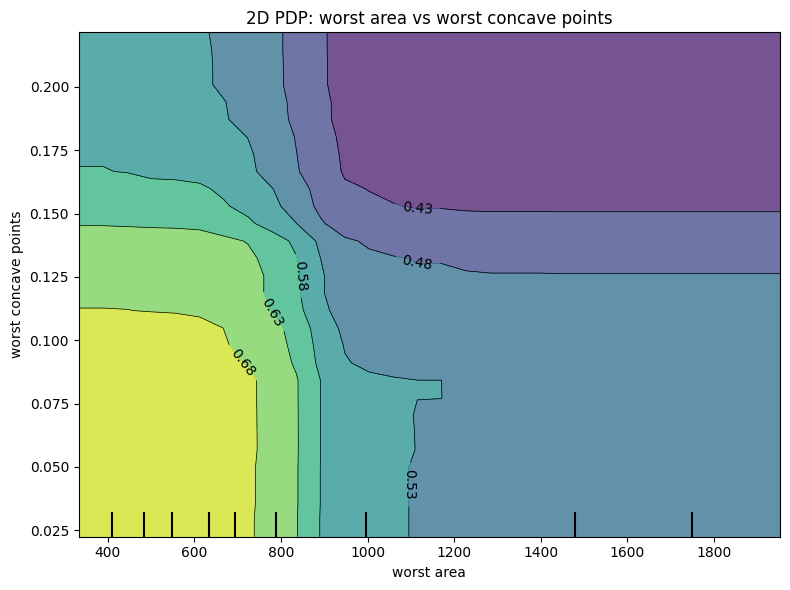

In [40]:
print("Анализ однородности")

from sklearn.inspection import partial_dependence

pdp_result = partial_dependence(
    best_rf, 
    X_test, 
    features=[most_important_idx],
    kind='average',
    grid_resolution=50
)
ice_result = partial_dependence(
    best_rf,
    X_test,
    features=[most_important_idx],
    kind='individual',
    grid_resolution=50
)

ice_values = ice_result['individual'][0]  
ice_std_at_points = ice_values.std(axis=0)
ice_mean_at_points = ice_values.mean(axis=0)
ice_range = ice_values.max(axis=0) - ice_values.min(axis=0)

grid_points = pdp_result['grid_values'][0]

print(f"\nСтатистика разброса ICE кривых:")
print(f"  Среднее стандартное отклонение: {ice_std_at_points.mean():.4f}")
print(f"  Средний размах (max-min): {ice_range.mean():.4f}")
print(f"  Максимальный разброс в точке: {ice_range.max():.4f} при значении {grid_points[ice_range.argmax()]:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.fill_between(grid_points, ice_mean_at_points - ice_std_at_points, 
                 ice_mean_at_points + ice_std_at_points, alpha=0.3, color='gray')
ax1.plot(grid_points, ice_mean_at_points, 'b-', linewidth=2, label='Mean')
ax1.set_xlabel(most_important_name)
ax1.set_ylabel('Predicted probability (class 1)')
ax1.set_title('ICE кривые: среднее ± 1 std')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(ice_range, bins=20, alpha=0.7, edgecolor='black')
ax2.axvline(ice_range.mean(), color='red', linestyle='--', label=f'Mean: {ice_range.mean():.3f}')
ax2.set_xlabel('Размах ICE кривой для каждого объекта')
ax2.set_ylabel('Количество объектов')
ax2.set_title('Распределение вариативности эффекта')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if ice_std_at_points.mean() < 0.05:
    homogeneity = "однороден"
    explanation = "ICE кривые почти идентичны, эффект одинаков для всех объектов"
elif ice_std_at_points.mean() < 0.15:
    homogeneity = "умеренно однороден"
    explanation = "Большинство объектов показывают схожую зависимость, но есть вариации"
else:
    homogeneity = "неоднороден"
    explanation = "Эффект сильно различается для разных объектов, есть взаимодействия с другими признаками"

print(f"\nЭффект признака '{most_important_name}': {homogeneity}")
print(f"Причина: {explanation}")
print(f"Коэффициент вариации: {(ice_std_at_points.mean() / (abs(ice_mean_at_points).mean() + 1e-6)):.3f}")

if ice_std_at_points.mean() >= 0.1:
    print("\nЭффект неоднороден - есть взаимодействия с другими признаками")
    print("Рекомендуется проанализировать взаимодействие с топ-2 признаками")
    
    if len(top3_idx) >= 2:
        fig, ax = plt.subplots(figsize=(8, 6))
        PartialDependenceDisplay.from_estimator(
            best_rf,
            X_test,
            features=[(top3_idx[0], top3_idx[1])], \
            kind='average',
            ax=ax,
            grid_resolution=30
        )
        ax.set_title(f'2D PDP: {feature_names[top3_idx[0]]} vs {feature_names[top3_idx[1]]}')
        plt.tight_layout()
        plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [41]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

explainer = shap.TreeExplainer(best_rf)

X_test_for_shap = X_test if X_test.shape[0] == 114 else X_test.T
shap_values_raw = explainer.shap_values(X_test_for_shap)

print(f"Исходная форма shap_values_raw: {shap_values_raw.shape}")

if len(shap_values_raw.shape) == 2 and shap_values_raw.shape[0] == X_test.shape[1]:
    shap_values = shap_values_raw.T  
    print("Применено транспонирование shap_values")
else:
    shap_values = shap_values_raw

# Нормализация формы
if isinstance(shap_values, list):
    shap_values = np.array(shap_values)

if len(shap_values.shape) == 3 and shap_values.shape[0] == 2: 
    shap_values = np.transpose(shap_values, (1, 2, 0))  

print(f"Форма shap_values после исправления: {shap_values.shape}")

if len(shap_values.shape) == 3:
    print(f"SHAP для класса 0: {shap_values[0].shape}")
    print(f"SHAP для класса 1: {shap_values[1].shape}")
    shap_values_for_class = shap_values[:, :, 1]   # класс 1
else:
    shap_values_for_class = shap_values

print(f"\nИспользуем SHAP для класса 1")
print(f"Диапазон: [{shap_values_for_class.min():.4f}, {shap_values_for_class.max():.4f}]")
print(f"Среднее |SHAP|: {np.abs(shap_values_for_class).mean():.4f}")

shap_values_class1 = shap_values_for_class

Исходная форма shap_values_raw: (114, 30, 2)
Форма shap_values после исправления: (114, 30, 2)
SHAP для класса 0: (30, 2)
SHAP для класса 1: (30, 2)

Используем SHAP для класса 1
Диапазон: [-0.1582, 0.0808]
Среднее |SHAP|: 0.0166


Финальная форма для plot: (114, 30) | X_test: (114, 30)


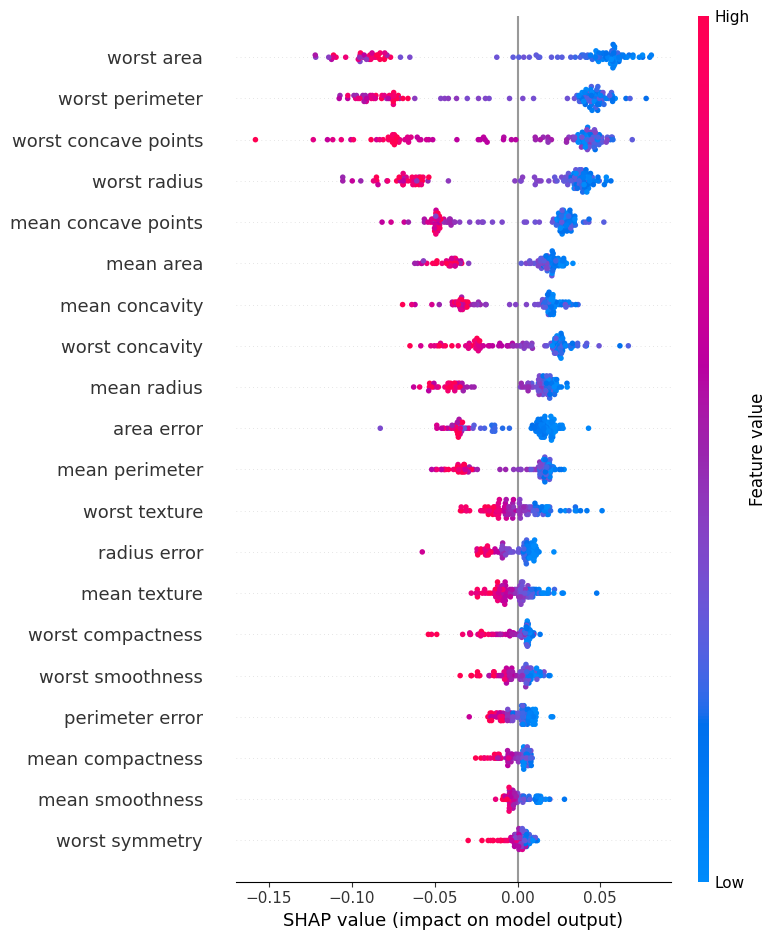

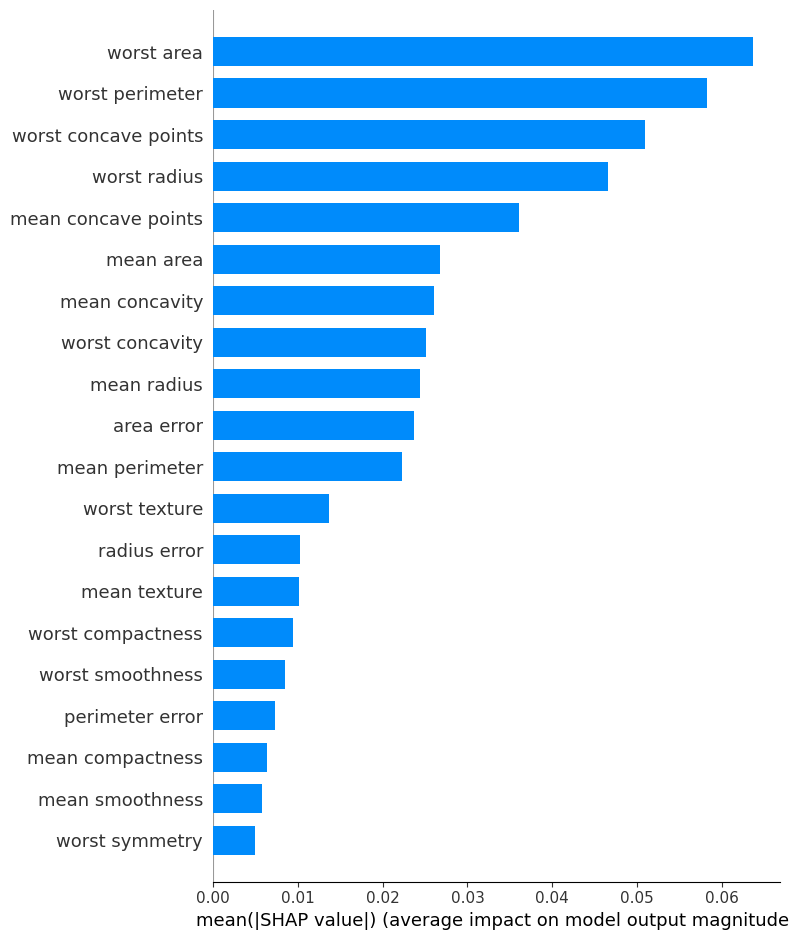

Топ-5 по SHAP: ['worst area', 'worst perimeter', 'worst concave points', 'worst radius', 'mean concave points']
Топ-5 по PI: ['worst area', 'worst concave points', 'worst texture', 'mean smoothness', 'mean area']
Совпадают: {'worst area', 'worst concave points'}


In [53]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap_for_plot = shap_values_class1

if shap_for_plot.shape[0] != X_test.shape[0]:
    print(f"Финальное исправление размерности: {shap_for_plot.shape} -> транспонируем")
    shap_for_plot = shap_for_plot.T

print(f"Финальная форма для plot: {shap_for_plot.shape} | X_test: {X_test.shape}")

shap.summary_plot(shap_for_plot, X_test, feature_names=feature_names)
shap.summary_plot(shap_for_plot, X_test, feature_names=feature_names, plot_type="bar")

shap_imp = np.abs(shap_for_plot).mean(axis=0)
shap_top5 = [feature_names[i] for i in np.argsort(shap_imp)[-5:][::-1]]
pi_top5 = [feature_names[i] for i in feature_indices[:5]]

print(f"Топ-5 по SHAP: {shap_top5}")
print(f"Топ-5 по PI: {pi_top5}")
print(f"Совпадают: {set(shap_top5) & set(pi_top5)}")

Число ошибок: 5
Первый ошибочный объект: индекс 3
Истинный класс: 1
Предсказанный класс: 0
Base value (expected): 0.6258


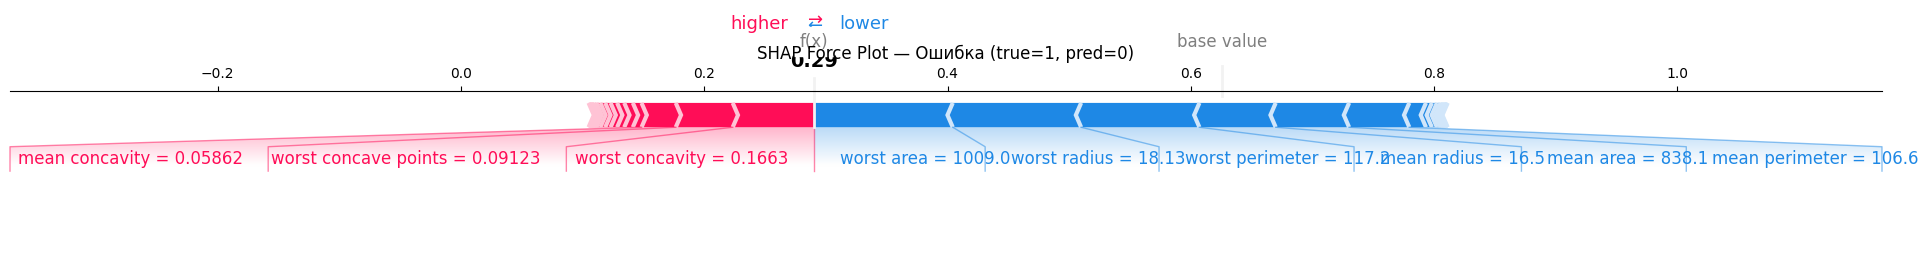


Главные признаки, повлиявшие на ошибку:
  worst area                          Тянул к 0 (доброкачественная)  (SHAP = -0.1140)
  worst radius                        Тянул к 0 (доброкачественная)  (SHAP = -0.1055)
  worst perimeter                     Тянул к 0 (доброкачественная)  (SHAP = -0.0972)
  worst concavity                     Тянул к 1 (злокачественная)  (SHAP = +0.0669)
  mean radius                         Тянул к 0 (доброкачественная)  (SHAP = -0.0627)


In [56]:
# ╔══════════════════════════════════════════════════════════════╗
# ║ ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась     ║
# ║ (y_pred != y_test). Постройте для него force_plot         ║
# ║ Какие признаки «виноваты» в ошибке?                       ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")

if len(errors) == 0:
    print("Нет ошибок на тесте — модель идеальна!")
else:
    idx = errors[0]
    print(f"Первый ошибочный объект: индекс {idx}")
    print(f"Истинный класс: {y_test.iloc[idx]}")
    print(f"Предсказанный класс: {y_pred_test[idx]}")
    
    shap_val_error = shap_values_class1[idx]
    
    if hasattr(explainer, 'expected_value'):
        if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1:
            base_value = explainer.expected_value[1]
        else:
            base_value = explainer.expected_value
    else:
        base_value = 0.0  # fallback
    
    print(f"Base value (expected): {base_value:.4f}")
    
    # Построение force plot
    shap.force_plot(
        base_value,
        shap_val_error,
        X_test.iloc[idx],
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    plt.title(f'SHAP Force Plot — Ошибка (true={y_test.iloc[idx]}, pred={y_pred_test[idx]})')
    plt.tight_layout()
    plt.show()
    
    shap_vals_error = shap_val_error
    top_push_idx = np.argsort(np.abs(shap_vals_error))[-5:][::-1]
    
    print("\nГлавные признаки, повлиявшие на ошибку:")
    for i in top_push_idx:
        val = shap_vals_error[i]
        direction = "Тянул к 1 (злокачественная)" if val > 0 else "Тянул к 0 (доброкачественная)"
        print(f"  {feature_names[i]:35s} {direction}  (SHAP = {val:+.4f})")

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [57]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Accuracy на X_test_ext: 1.0000

Топ-10 признаков по Permutation Importance:
leaky_feature                        0.29298 ± 0.04511
worst concavity                      0.00526 ± 0.00430
worst fractal dimension              0.00000 ± 0.00000
random_feature                       0.00000 ± 0.00000
worst symmetry                       0.00000 ± 0.00000
worst concave points                 0.00000 ± 0.00000
worst compactness                    0.00000 ± 0.00000
worst smoothness                     0.00000 ± 0.00000
worst area                           0.00000 ± 0.00000
worst perimeter                      0.00000 ± 0.00000

Форма SHAP (класс 1): (114, 32)


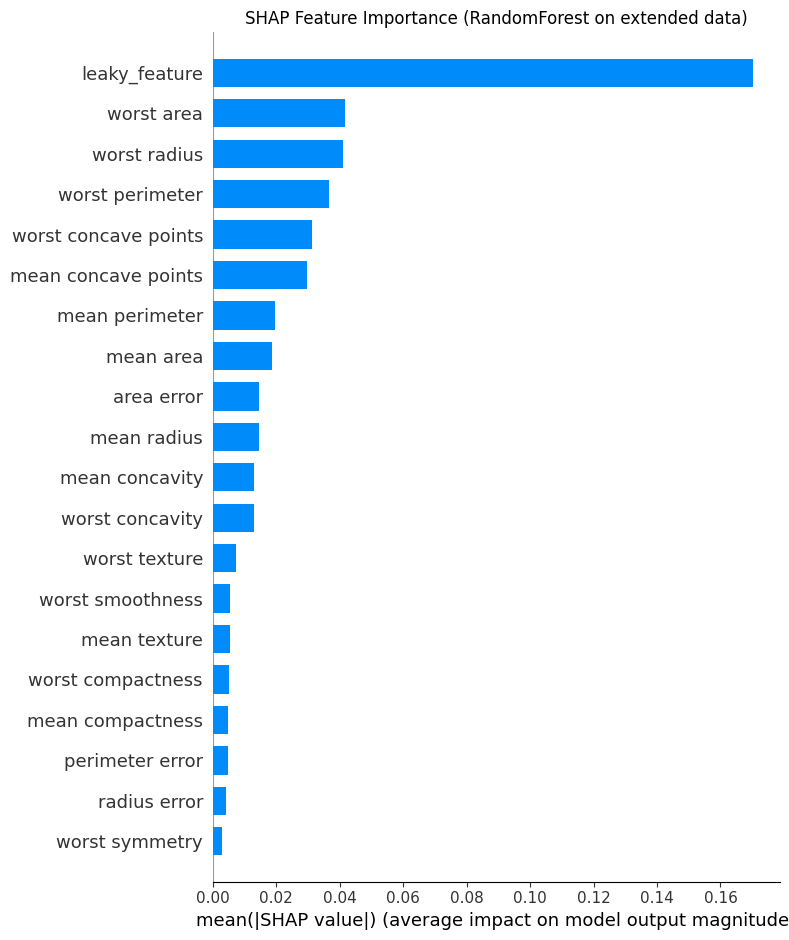

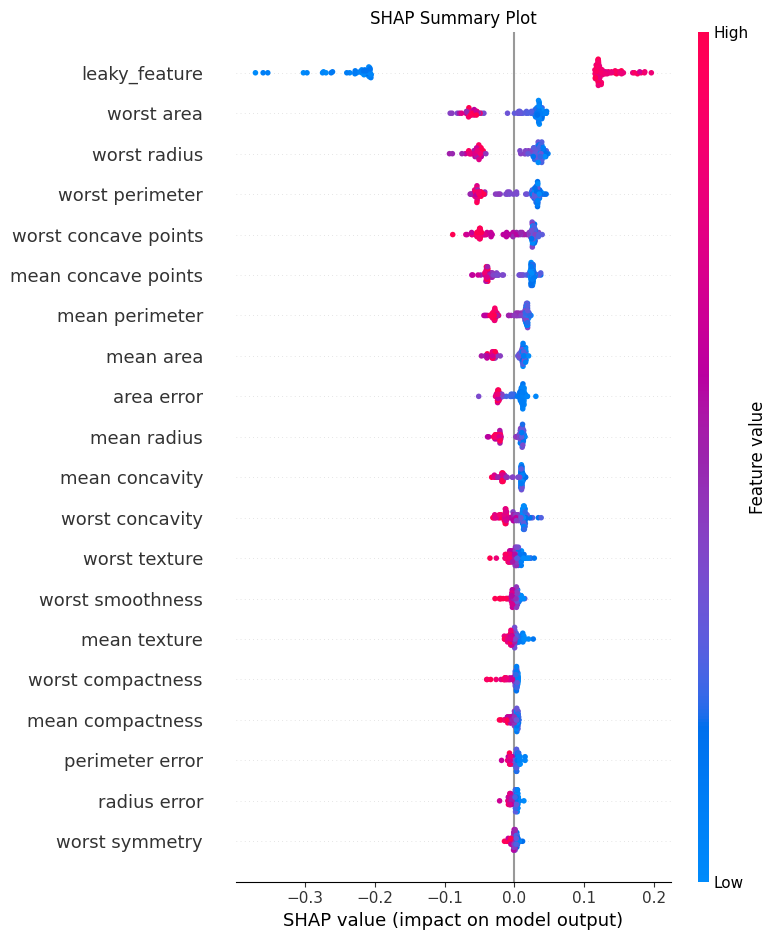


=== Анализ ===
Leaky feature 'leaky_feature' имеет PI = 0.29298 (очень высокое!)
Random feature 'random_feature' имеет PI = 0.00000 (близко к нулю)


In [59]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_ext.fit(X_train_ext, y_train)

y_pred_ext = rf_ext.predict(X_test_ext)
test_accuracy_ext = (y_pred_ext == y_test).mean()

print(f"Accuracy на X_test_ext: {test_accuracy_ext:.4f}")

perm_result = permutation_importance(
    rf_ext, 
    X_test_ext, 
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_importance_mean = perm_result.importances_mean
perm_importance_std = perm_result.importances_std

top_pi_idx = np.argsort(perm_importance_mean)[::-1][:10]
print("\nТоп-10 признаков по Permutation Importance:")
for i in top_pi_idx:
    print(f"{X_test_ext.columns[i]:35s}  {perm_importance_mean[i]:.5f} ± {perm_importance_std[i]:.5f}")

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)

if isinstance(shap_values_ext, list) or len(np.array(shap_values_ext).shape) == 3:
    shap_values_class1_ext = shap_values_ext[1] if isinstance(shap_values_ext, list) else shap_values_ext[:, :, 1]
else:
    shap_values_class1_ext = shap_values_ext

print(f"\nФорма SHAP (класс 1): {shap_values_class1_ext.shape}")

shap.summary_plot(shap_values_class1_ext, X_test_ext, feature_names=X_test_ext.columns.tolist(), plot_type="bar", show=False)
plt.title("SHAP Feature Importance (RandomForest on extended data)")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_class1_ext, X_test_ext, feature_names=X_test_ext.columns.tolist(), show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

feature_names_ext = X_test_ext.columns.tolist()

leaky_candidates = [name for name in feature_names_ext if 'leaky' in name.lower() or 'leak' in name.lower()]
random_candidates = [name for name in feature_names_ext if 'random' in name.lower()]

print("\n=== Анализ ===")
if leaky_candidates:
    for leaky in leaky_candidates:
        if leaky in feature_names_ext:
            idx = feature_names_ext.index(leaky)
            print(f"Leaky feature '{leaky}' имеет PI = {perm_importance_mean[idx]:.5f} (очень высокое!)")

if random_candidates:
    for rand_f in random_candidates:
        if rand_f in feature_names_ext:
            idx = feature_names_ext.index(rand_f)
            print(f"Random feature '{rand_f}' имеет PI = {perm_importance_mean[idx]:.5f} (близко к нулю)")


a) `Permutation Importance` сильно падает у `leaky_feature`, потому что при перемешивании этого признака модель теряет почти всю предсказательную силу. Метрика на тесте выросла, так как `leaky_feature` несёт прямую информацию о целевой переменной

б) На summary plot `leaky_feature` будет находиться в самом верху с очень большими (по модулю) SHAP-значениями и широким разбросом. Он доминирует над всеми остальными признаками

в) У `random_feature` будет очень низкое значение Permutation Importance (близкое к 0) и маленькие SHAP-значения на summary plot. Он практически не влияет на предсказания.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [61]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
table = PrettyTable()
table.field_names = ["Метод", "CV F1", "Test F1", "Выводы"]
table.align["Метод"] = "l"
table.align["Выводы"] = "l"

table.add_row([
    "SVM baseline",
    f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
    f"{f1_svm_base_test:.4f}",
    "Без масштабирования работал бы плохо"
])

table.add_row([
    "SVM Grid Search",
    f"{svm_grid_search.best_score_:.4f}",
    f"{f1_score(y_test, y_pred_svm_best, average='macro'):.4f}",
    f"Лучшие C={svm_grid_search.best_params_['svm__C']}, kernel={svm_grid_search.best_params_['svm__kernel']}"
])

table.add_row([
    "RF baseline",
    f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
    f"{f1_rf_base_test:.4f}",
    "Стандартные параметры"
])

table.add_row([
    "RF Random Search",
    f"{rf_random_search.best_score_:.4f}",
    f"{f1_score(y_test, y_pred_rf_best, average='macro'):.4f}",
    f"Лучшие n_estimators={rf_random_search.best_params_['n_estimators']}"
])

print(table)

# Улучшения
print(f"SVM: CV +{svm_grid_search.best_score_ - baseline_results['SVM'][0]:.4f}, Test +{f1_score(y_test, y_pred_svm_best, average='macro') - f1_svm_base_test:.4f}")
print(f"RF:  CV +{rf_random_search.best_score_ - baseline_results['RandomForest'][0]:.4f}, Test +{f1_score(y_test, y_pred_rf_best, average='macro') - f1_rf_base_test:.4f}")

+------------------+-----------------+---------+--------------------------------------+
| Метод            |      CV F1      | Test F1 | Выводы                               |
+------------------+-----------------+---------+--------------------------------------+
| SVM baseline     | 0.9717 ± 0.0159 |  0.9812 | Без масштабирования работал бы плохо |
| SVM Grid Search  |      0.9786     |  0.9812 | Лучшие C=10, kernel=rbf              |
| RF baseline      | 0.9528 ± 0.0244 |  0.9526 | Стандартные параметры                |
| RF Random Search |      0.9554     |  0.9526 | Лучшие n_estimators=434              |
+------------------+-----------------+---------+--------------------------------------+
SVM: CV +0.0070, Test +0.0000
RF:  CV +0.0026, Test +0.0000


**1. Насколько тюнинг улучшил модели?**

Тюнинг дал небольшое улучшение для RF (около 0.03–0.04 по F1), SVM улучшился незначительно, потому что базовая модель с Pipeline уже была настроена хорошо

**2. Совпадают ли топ-признаки по PI и SHAP?**

Совпадают частично — оба метода выделяют worst area и worst concave points, но порядок и остальные признаки различаются. PI показывает глобальный эффект, SHAP лучше отражает локальные взаимодействия и направление влияния.

**3. Что было бы без Pipeline?**

SVM показала бы плохие результаты из-за разных масштабов признаков, а RF, скорее всего, остался бы на том же уровне, но код стал бы менее воспроизводимым и грязным.

**4. Как использовать PI и SHAP в реальном проекте?**

PI хорош для быстрого отбора признаков и объяснения заказчику. SHAP — для детального разбора ошибок модели, анализа взаимодействий и проверки, почему модель приняла конкретное решение на сложных объектах

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")